In [223]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

In [224]:
data_stores=pd.read_csv("./Rossmann/store.csv", index_col="Store")
data_stores

,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Store,,,,,,,,,
1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


In [225]:
data_stores["StoreType"].value_counts()

StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

In [226]:
data_stores["Assortment"].value_counts()

Assortment
a    593
c    513
b      9
Name: count, dtype: int64

In [227]:
data_stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 1 to 1115
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StoreType                  1115 non-null   str    
 1   Assortment                 1115 non-null   str    
 2   CompetitionDistance        1112 non-null   float64
 3   CompetitionOpenSinceMonth  761 non-null    float64
 4   CompetitionOpenSinceYear   761 non-null    float64
 5   Promo2                     1115 non-null   int64  
 6   Promo2SinceWeek            571 non-null    float64
 7   Promo2SinceYear            571 non-null    float64
 8   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(1), str(3)
memory usage: 89.3 KB


In [228]:
data_todas_tiendas=pd.read_csv("./Rossmann/train.csv", parse_dates=["Date"])
data_todas_tiendas

C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_43792\326317569.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  data_todas_tiendas=pd.read_csv("./Rossmann/train.csv", parse_dates=["Date"])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931
...,...,...,...,...,...,...,...,...,...,...
1001594,1111,2,2013-01-01,0,0,0,0,a,1,225066
1001595,1112,2,2013-01-01,0,0,0,0,a,1,775592
1001596,1113,2,2013-01-01,0,0,0,0,a,1,135205
1001597,1114,2,2013-01-01,0,0,0,0,a,1,954751


In [229]:
data_todas_tiendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001599 entries, 0 to 1001598
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1001599 non-null  int64         
 1   DayOfWeek      1001599 non-null  int64         
 2   Date           1001599 non-null  datetime64[us]
 3   Sales          1001599 non-null  int64         
 4   Customers      1001599 non-null  int64         
 5   Open           1001599 non-null  int64         
 6   Promo          1001599 non-null  int64         
 7   StateHoliday   1001599 non-null  object        
 8   SchoolHoliday  1001599 non-null  int64         
 9   Id             1001599 non-null  int64         
dtypes: datetime64[us](1), int64(8), object(1)
memory usage: 76.4+ MB


In [230]:
data_todas_tiendas.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
Id                        int64
dtype: object

In [231]:
data_tienda1=data_todas_tiendas[data_todas_tiendas["Store"]==1].sort_values(by="Date", ascending=True)
data_tienda1

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
1000485,1,2,2013-01-01,0,0,0,0,a,1,690197
999370,1,3,2013-01-02,5530,668,1,0,0,1,988300
998255,1,4,2013-01-03,4327,578,1,0,0,1,919910
997140,1,5,2013-01-04,4486,619,1,0,0,1,662609
996025,1,6,2013-01-05,4997,635,1,0,0,1,1008092
...,...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-13,5054,553,1,1,0,0,308477
3345,1,2,2015-07-14,5042,544,1,1,0,0,704685
2230,1,3,2015-07-15,4767,550,1,1,0,0,64663
1115,1,4,2015-07-16,4427,517,1,1,0,0,324709


In [232]:
aux=np.array(data_tienda1["Date"][1:])-np.array(data_tienda1["Date"][0:-1].values)
aux.shape


(927,)

In [233]:
num_unicos=len(set(aux))
print(num_unicos)

1


In [234]:
px.line(data_frame=data_tienda1, y=["Sales","Customers"], x="Date")

In [235]:
corr_=data_tienda1.corr(numeric_only=True)

In [236]:
corr_.info()


<class 'pandas.DataFrame'>
Index: 8 entries, Store to Id
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Store          0 non-null      float64
 1   DayOfWeek      7 non-null      float64
 2   Sales          7 non-null      float64
 3   Customers      7 non-null      float64
 4   Open           7 non-null      float64
 5   Promo          7 non-null      float64
 6   SchoolHoliday  7 non-null      float64
 7   Id             7 non-null      float64
dtypes: float64(8)
memory usage: 629.0 bytes


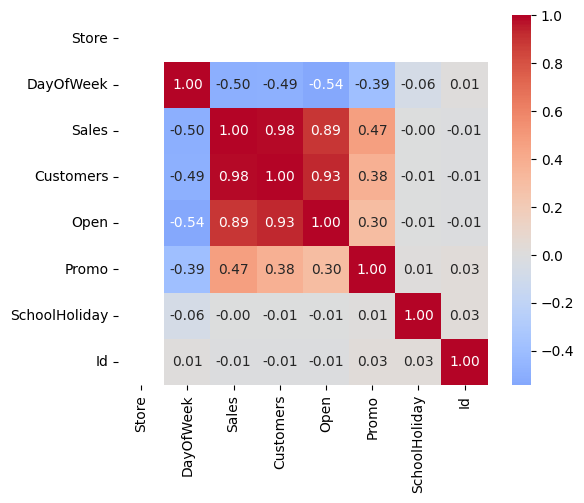

In [237]:
##Heatmap correlaciones
import seaborn as sns
corr=data_tienda1.corr


sns.heatmap(corr_,
            annot=True, 
            fmt=".2f",
            square=True, 
            cmap="coolwarm",
            center=0
)
plt.show()

In [238]:
corr_

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,Id
Store,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DayOfWeek,NaN,1.000000,-0.500584,-0.494103,-0.543158,-0.393238,-0.062546,0.012304
Sales,NaN,-0.500584,1.000000,0.984457,0.889231,0.469716,-0.001119,-0.011427
Customers,NaN,-0.494103,0.984457,1.000000,0.927731,0.376747,-0.006127,-0.011916
Open,NaN,-0.543158,0.889231,0.927731,1.000000,0.299066,-0.005612,-0.012078
Promo,NaN,-0.393238,0.469716,0.376747,0.299066,1.000000,0.011485,0.025855
SchoolHoliday,NaN,-0.062546,-0.001119,-0.006127,-0.005612,0.011485,1.000000,0.026569
Id,NaN,0.012304,-0.011427,-0.011916,-0.012078,0.025855,0.026569,1.000000


In [239]:
data_tienda1=data_tienda1.drop("Customers", axis=1).copy()
data_tienda1

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,Id
1000485,1,2,2013-01-01,0,0,0,a,1,690197
999370,1,3,2013-01-02,5530,1,0,0,1,988300
998255,1,4,2013-01-03,4327,1,0,0,1,919910
997140,1,5,2013-01-04,4486,1,0,0,1,662609
996025,1,6,2013-01-05,4997,1,0,0,1,1008092
...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-13,5054,1,1,0,0,308477
3345,1,2,2015-07-14,5042,1,1,0,0,704685
2230,1,3,2015-07-15,4767,1,1,0,0,64663
1115,1,4,2015-07-16,4427,1,1,0,0,324709


In [240]:
data_tienda1.iloc[1,6]

'0'

In [241]:
data_tienda1["Open"].unique()

array([0, 1])

In [242]:
data_tienda1["Promo"].unique()

array([0, 1])

In [243]:
data_tienda1["StateHoliday"].unique()

array(['a', '0', 0, 'b', 'c'], dtype=object)

In [244]:
data_tienda1.loc[data_tienda1["StateHoliday"]==0, "StateHoliday"]="0"

In [245]:
data_tienda1["StateHoliday"].unique()


array(['a', '0', 'b', 'c'], dtype=object)

In [246]:
data_tienda1["SchoolHoliday"].unique()

array([1, 0])

In [247]:
data_tienda1["festivo"]=1*((data_tienda1["StateHoliday"]!="0") | (data_tienda1["SchoolHoliday"]!=0))
data_tienda1

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,Id,festivo
1000485,1,2,2013-01-01,0,0,0,a,1,690197,1
999370,1,3,2013-01-02,5530,1,0,0,1,988300,1
998255,1,4,2013-01-03,4327,1,0,0,1,919910,1
997140,1,5,2013-01-04,4486,1,0,0,1,662609,1
996025,1,6,2013-01-05,4997,1,0,0,1,1008092,1
...,...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-13,5054,1,1,0,0,308477,0
3345,1,2,2015-07-14,5042,1,1,0,0,704685,0
2230,1,3,2015-07-15,4767,1,1,0,0,64663,0
1115,1,4,2015-07-16,4427,1,1,0,0,324709,0


In [248]:
meses=[x.month for x in data_tienda1["Date"]]
data_tienda1["mes"]=meses
data_tienda1

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,Id,festivo,mes
1000485,1,2,2013-01-01,0,0,0,a,1,690197,1,1
999370,1,3,2013-01-02,5530,1,0,0,1,988300,1,1
998255,1,4,2013-01-03,4327,1,0,0,1,919910,1,1
997140,1,5,2013-01-04,4486,1,0,0,1,662609,1,1
996025,1,6,2013-01-05,4997,1,0,0,1,1008092,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-13,5054,1,1,0,0,308477,0,7
3345,1,2,2015-07-14,5042,1,1,0,0,704685,0,7
2230,1,3,2015-07-15,4767,1,1,0,0,64663,0,7
1115,1,4,2015-07-16,4427,1,1,0,0,324709,0,7


In [371]:
fechas=data_tienda1["Date"].values
target=data_tienda1["Sales"].values
mes=data_tienda1["mes"].values
festivo=data_tienda1["festivo"].values
day_of_week=data_tienda1["DayOfWeek"].values

promo = data_tienda1["Promo"].values
open_ = data_tienda1["Open"].values

(array([159.,   0.,   0.,   0.,   1.,   3.,  20., 111., 149., 137., 124.,
        111.,  52.,  25.,  14.,   9.,   8.,   3.,   0.,   2.]),
 array([   0. ,  476.4,  952.8, 1429.2, 1905.6, 2382. , 2858.4, 3334.8,
        3811.2, 4287.6, 4764. , 5240.4, 5716.8, 6193.2, 6669.6, 7146. ,
        7622.4, 8098.8, 8575.2, 9051.6, 9528. ]),
 <BarContainer object of 20 artists>)

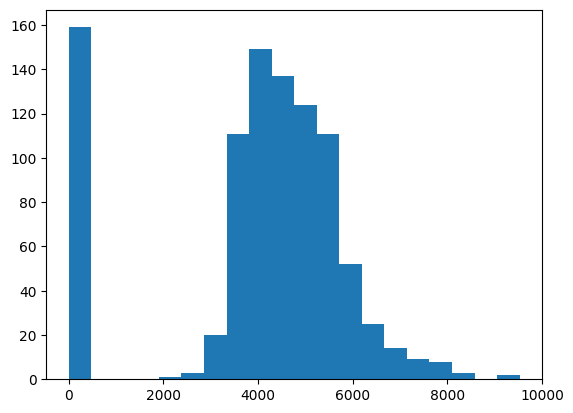

In [250]:
plt.hist(target, bins=20)

### Modelo "dummy" (persistente)

Es un modelo que predice para mañana lo mismo que hoy

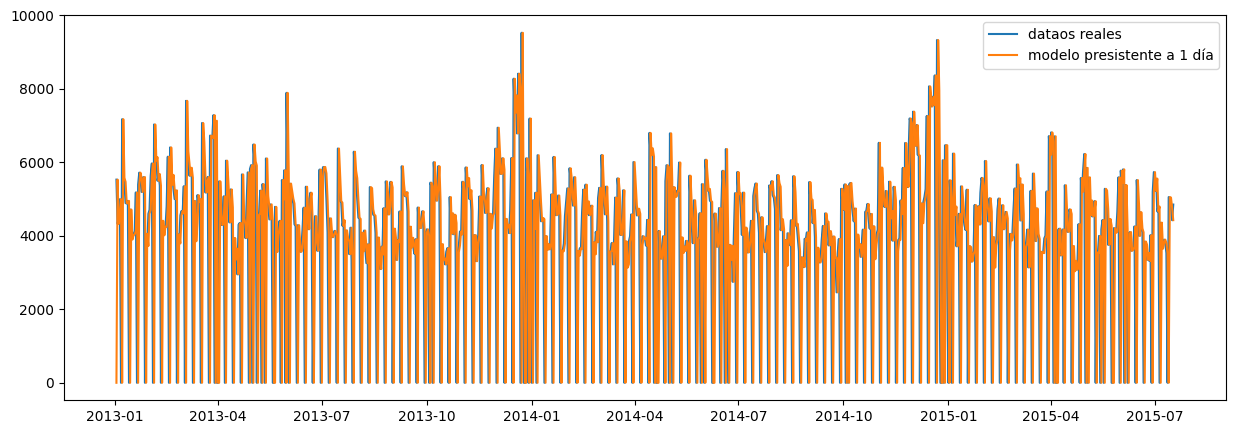

In [251]:
fechas_comparacion=fechas[1:]
target_comparacion=target[1:]
pred_persistente=target[0:-1]

plt.figure(figsize=(15,5))
plt.plot(fechas_comparacion, target_comparacion, label="dataos reales")
plt.plot(fechas_comparacion, pred_persistente, label="modelo presistente a 1 día")
plt.legend()

In [252]:
from sklearn.metrics import r2_score as R2_score # coeficiente de determinación

R2_score(target_comparacion, pred_persistente)

-1.2577293520039978

In [253]:
lim=28
R2_score_persistente=[]
for desplazamiento in range(0,4*7+1):
    fechas_comparacion=fechas[desplazamiento:]
    target_comparacion=target[desplazamiento:]
    modelo_persistente=target[0:(len(target)-desplazamiento)]
    R2_score_persistente.append(R2_score(target_comparacion, modelo_persistente))
    print(f"R2 del Modelo persistente cuando deltaT ({desplazamiento}): R2={R2_score_persistente[desplazamiento]:.2f}")
    


R2 del Modelo persistente cuando deltaT (0): R2=1.00
R2 del Modelo persistente cuando deltaT (1): R2=-1.26
R2 del Modelo persistente cuando deltaT (2): R2=-1.08
R2 del Modelo persistente cuando deltaT (3): R2=-0.87
R2 del Modelo persistente cuando deltaT (4): R2=-1.01
R2 del Modelo persistente cuando deltaT (5): R2=-1.22
R2 del Modelo persistente cuando deltaT (6): R2=-1.46
R2 del Modelo persistente cuando deltaT (7): R2=0.26
R2 del Modelo persistente cuando deltaT (8): R2=-1.49
R2 del Modelo persistente cuando deltaT (9): R2=-1.31
R2 del Modelo persistente cuando deltaT (10): R2=-1.00
R2 del Modelo persistente cuando deltaT (11): R2=-0.99
R2 del Modelo persistente cuando deltaT (12): R2=-1.17
R2 del Modelo persistente cuando deltaT (13): R2=-1.30
R2 del Modelo persistente cuando deltaT (14): R2=0.44
R2 del Modelo persistente cuando deltaT (15): R2=-1.32
R2 del Modelo persistente cuando deltaT (16): R2=-1.12
R2 del Modelo persistente cuando deltaT (17): R2=-0.95
R2 del Modelo persisten

In [254]:
max(R2_score_persistente, )

1.0

Text(0, 0.5, 'R2 Score del modelo persistente')

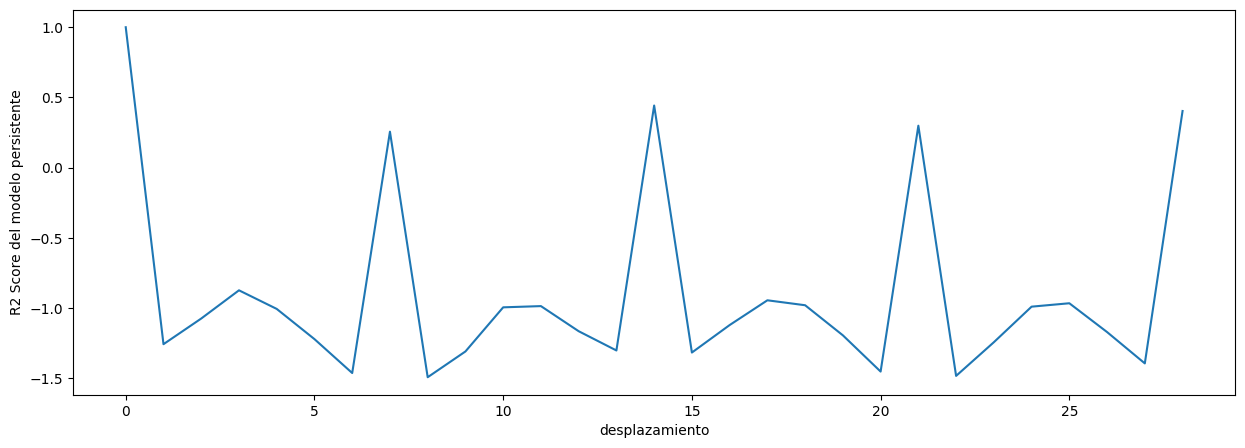

In [255]:
plt.figure(figsize=(15,5))
plt.plot(R2_score_persistente)
plt.xlabel("desplazamiento")
plt.ylabel("R2 Score del modelo persistente")

### Conclusión:

- Hay una estacionalidad muy clara (ciclos) cada 7/14 días
- Mi modelo predictivo debería batir claramente el R2 score de 0.44 (modelo persistente de 14 días)

In [256]:
target=data_tienda1["Sales"]

In [257]:
col_num_list=data_tienda1.select_dtypes(include="number").columns.tolist()
print(col_num_list)
col_transf_list=["Sales"]

['Store', 'DayOfWeek', 'Sales', 'Open', 'Promo', 'SchoolHoliday', 'Id', 'festivo', 'mes']


In [258]:
print(col_transf_list)


['Sales']


In [259]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class Clipper(BaseEstimator, TransformerMixin):
    def __init__(self, low=1, high=99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        # 🔹 Forzar DataFrame internamente
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        self.feature_names_in_ = X.columns

        self.lower_ = X.quantile(self.low / 100)
        self.upper_ = X.quantile(self.high / 100)

        return self

    def transform(self, X):
        # 🔹 Convertir a DataFrame si viene como array
        is_array = not isinstance(X, pd.DataFrame)

        if is_array:
            X = pd.DataFrame(X, columns=self.feature_names_in_)

        X_clipped = X.clip(lower=self.lower_, upper=self.upper_, axis=1)

        # 🔹 devolver mismo tipo que recibió
        return X_clipped.values if is_array else X_clipped

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

In [260]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

pipe_target=Pipeline([
    ("clip", Clipper(1, 98)),
    ("scale", MinMaxScaler())
])

preprocessing_target=ColumnTransformer([
    ('num', pipe_target, col_transf_list)
], remainder='passthrough',
verbose_feature_names_out=False )  # 🔥 CLAVE)

transf_=Pipeline([
    ("pre", preprocessing_target)
]).set_output(transform='pandas')

In [261]:
punto_corte=int(len(data_tienda1["Sales"])*0.8)
print(punto_corte)
Nval=200
W=14

742


In [262]:
#Aux
data_tienda1_aux=data_tienda1[:punto_corte]

#Training
data_tienda1_train=data_tienda1_aux[:-Nval]

#Validacion
data_tienda1_val=data_tienda1[-Nval:]

#Test
data_tienda1_test=data_tienda1[punto_corte:]

In [263]:
print(f"data train shape{data_tienda1_train.shape}")
print(f"data Val shape{data_tienda1_val.shape}")
print(f"data Test shape{data_tienda1_test.shape}")

data train shape(542, 11)
data Val shape(200, 11)
data Test shape(186, 11)


In [264]:
#Transformacion dataset entrenamiento
data_tienda1_transform_train=transf_.fit_transform(data_tienda1_train)

#Transformacion dataset validación
data_tienda1_transform_val=transf_.transform(data_tienda1_val)

#Transformacion dataset test
data_tienda1_transform_test=transf_.transform(data_tienda1_test)

In [265]:
Sales_train=data_tienda1_transform_train["Sales"]
Sales_val=data_tienda1_transform_val["Sales"]
Sales_test=data_tienda1_transform_test["Sales"]

In [266]:
print(data_tienda1_transform_test.shape)

(186, 11)


In [267]:
df_tienda1_transf= pd.concat([data_tienda1_transform_train, data_tienda1_transform_val, data_tienda1_transform_test], axis=0, ignore_index=True)

In [268]:
df_tienda1_transf.shape

(928, 11)

### Primer modelo: solo la serie endógena (target)

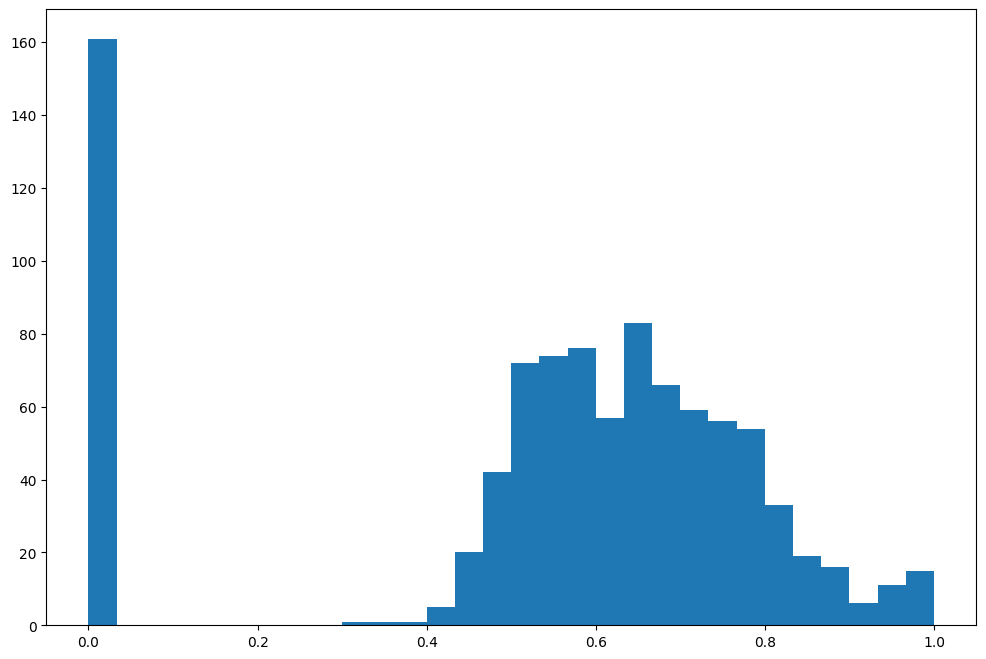

In [269]:
plt.figure(figsize=(12,8))
plt.hist(df_tienda1_transf["Sales"], bins=30)
plt.show()

In [270]:
Sales_transf=np.array(df_tienda1_transf["Sales"])
print(type(Sales_transf))

<class 'numpy.ndarray'>


In [353]:
df_tienda1_transf

,Sales,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,Id,festivo,mes
0,0.000000,1,2,2013-01-01,0,0,a,1,690197,1,1
1,0.774518,1,3,2013-01-02,1,0,0,1,988300,1,1
2,0.606029,1,4,2013-01-03,1,0,0,1,919910,1,1
3,0.628298,1,5,2013-01-04,1,0,0,1,662609,1,1
4,0.699868,1,6,2013-01-05,1,0,0,1,1008092,1,1
...,...,...,...,...,...,...,...,...,...,...,...
923,0.707851,1,1,2015-07-13,1,1,0,0,308477,0,7
924,0.706170,1,2,2015-07-14,1,1,0,0,704685,0,7
925,0.667655,1,3,2015-07-15,1,1,0,0,64663,0,7
926,0.620035,1,4,2015-07-16,1,1,0,0,324709,0,7


In [271]:
from my_utils_series_temporales import enventanar, info_enventanado

# estas tres listas deben tener el mismo número de elementos:
series         = [Sales_transf]
nombres_series = ["target_transf"]
se_saben_antes = [False]

In [272]:
W=14

In [273]:
X, y = enventanar(series, target=0, se_saben_antes=se_saben_antes, W_in=W)

In [274]:
print(Sales_transf[:10])

[0.         0.77451848 0.6060292  0.62829836 0.69986779 0.
 1.         0.78152136 0.76625508 0.68516174]


In [275]:
Sales_transf.shape

(928,)

In [276]:
X.shape, y.shape

((928, 14, 1), (928,))

In [277]:
X[:10]

array([[[       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan]],

       [[       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [0.        ]],

       [[       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [       nan],
        [0.        ],
        [0.77451848]],

       [[       nan],
        [       nan],
        [       nan],
    

In [278]:
y[:3]

array([0.        , 0.77451848, 0.6060292 ])

In [279]:
punto_corte=int(len(X)*0.8)
print(punto_corte)

742


In [280]:
Nval=200

In [281]:
#Aux
X_aux=X[W:punto_corte]
fechas_aux=fechas[W:punto_corte]
target_aux=target[W:punto_corte]
y_aux=y[W:punto_corte]

#Training
X_train=X_aux[:-Nval]
fechas_train=fechas_aux[:-Nval]
target_train=target_aux[:-Nval]
y_train=y_aux[:-Nval]

#Validacion
X_val=X_aux[-Nval:]
fechas_val=fechas_aux[-Nval:]
target_val=target_aux[-Nval:]
y_val=y_aux[-Nval:]

#Test
X_test=X[punto_corte:]
fechas_test=fechas[punto_corte:]
target_test=target[punto_corte:]
y_test=y[punto_corte:]


In [282]:
print(f"X_train shape: {X_train.shape}, y_train {y_train.shape}, fechas_train {fechas_train.shape}")


X_train shape: (528, 14, 1), y_train (528,), fechas_train (528,)


In [283]:
print(f"X_val shape: {X_val.shape}, y_val {y_val.shape}, fechas_train {fechas_val.shape}")

X_val shape: (200, 14, 1), y_val (200,), fechas_train (200,)


In [284]:
print(f"X_test shape: {X_test.shape}, y_val {y_test.shape}, fechas_train {fechas_test.shape}")

X_test shape: (186, 14, 1), y_val (186,), fechas_train (186,)


In [285]:
from tensorflow import keras
from tensorflow.keras.layers import Dense, LSTM, RNN
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers.legacy import Adam, RMSprop

model=Sequential()
model.add(LSTM(5, input_shape=X.shape[1:]))
model.add(Dense(1, activation="relu"))

optimizer_lstm= keras.optimizers.RMSprop(learning_rate=1/1000)

model.compile(optimizer=optimizer_lstm, loss="mean_squared_error")

model.summary()

c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\env-PC4-mbit\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 5)              │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146 (584.00 B)

 Trainable params: 146 (584.00 B)

 Non-trainable params: 0 (0.00 B)

### Primer modelo: solo la serie endógena (target)

In [286]:
help(getcwd)

Help on built-in function getcwd in module nt:

getcwd()
    Return a unicode string representing the current working directory.



In [287]:
from os import getcwd

cwd_=getcwd()
print(type(cwd_))

cwd_transf = cwd_.replace("\\", "/")
print(cwd_transf)
filepath_model=cwd_transf+"/bestmodel.keras"
print(filepath_model)

<class 'str'>
c:/Users/CHOPPE/Desktop/Software Development/Series_temporales_redes_recurrentes_rossmann
c:/Users/CHOPPE/Desktop/Software Development/Series_temporales_redes_recurrentes_rossmann/bestmodel.keras


In [288]:
help(keras.callbacks.ModelCheckpoint)

Help on class ModelCheckpoint in module keras.src.callbacks.model_checkpoint:

class ModelCheckpoint(keras.src.callbacks.monitor_callback.MonitorCallback)
 |  ModelCheckpoint(filepath, monitor='val_loss', verbose=0, save_best_only=False, save_weights_only=False, mode='auto', save_freq='epoch', initial_value_threshold=None)
 |
 |  Callback to save the Keras model or model weights at some frequency.
 |
 |  `ModelCheckpoint` callback is used in conjunction with training using
 |  `model.fit()` to save a model or weights (in a checkpoint file) at some
 |  interval, so the model or weights can be loaded later to continue the
 |  training from the state saved.
 |
 |  A few options this callback provides include:
 |
 |  - Whether to only keep the model that has achieved the "best performance" so
 |    far, or whether to save the model at the end of every epoch regardless of
 |    performance.
 |  - Definition of "best"; which quantity to monitor and whether it should be
 |    maximized or min

In [289]:
epochs=500
batchsize=64

losses_train=[]
losses_val=[]


Check=ModelCheckpoint(filepath_model, monitor="val_loss", verbose=2, save_best_only=True)

In [290]:
help(keras.Sequential)

Help on class Sequential in module keras.src.models.sequential:

class Sequential(keras.src.models.model.Model)
 |  Sequential(*args, **kwargs)
 |
 |  `Sequential` groups a linear stack of layers into a `Model`.
 |
 |  Examples:
 |
 |  ```python
 |  model = keras.Sequential()
 |  model.add(keras.Input(shape=(16,)))
 |  model.add(keras.layers.Dense(8))
 |
 |  # Note that you can also omit the initial `Input`.
 |  # In that case the model doesn't have any weights until the first call
 |  # to a training/evaluation method (since it isn't yet built):
 |  model = keras.Sequential()
 |  model.add(keras.layers.Dense(8))
 |  model.add(keras.layers.Dense(4))
 |  # model.weights not created yet
 |
 |  # Whereas if you specify an `Input`, the model gets built
 |  # continuously as you are adding layers:
 |  model = keras.Sequential()
 |  model.add(keras.Input(shape=(16,)))
 |  model.add(keras.layers.Dense(8))
 |  len(model.weights)  # Returns "2"
 |
 |  # When using the delayed-build pattern (no 

In [291]:
Sales_train=data_tienda1_train["Sales"]
Sales_val=data_tienda1_val["Sales"]
Sales_test=data_tienda1_test["Sales"]


In [292]:
from matplotlib.ticker import MaxNLocator

def grafica_entrenamiento(tr_mse, val_mse):
    ax=plt.figure(figsize=(10,4)).gca()
    plt.plot(1+np.arange(len(tr_mse)), tr_mse) #np.arange(3) → [0, 1, 2]
    plt.plot(1+np.arange(len(val_mse)), val_mse) #np.arange(3) → [0, 1, 2]
    plt.title('mse del modelo', fontsize=18)
    plt.xlabel('epoca', fontsize=18)
    plt.ylabel('mse', fontsize=18)
    plt.legend(['entrenamiento', 'validación'], loc='upper left')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

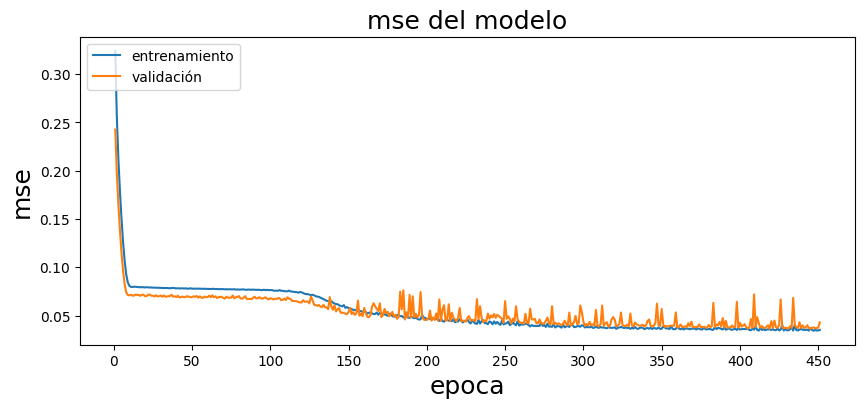


Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss did not improve from 0.03648

Epoch 1: val_loss improved from 0.03648 to 0.03633, saving model to c:/Users/CHOPPE/Desktop/Software Development/Series_temporales_rede

In [293]:
from IPython.display import clear_output
losses_train=[]
losses_val=[]

for i in range (epochs):
    history=model.fit(X_train, y_train, batch_size=64, epochs=1, verbose=0, callbacks=Check, validation_data=(X_val, y_val))
    losses_train.append(history.history["loss"])
    losses_val.append(history.history["val_loss"])
    if (i%50)==0:
        clear_output()
        grafica_entrenamiento(losses_train, losses_val)





In [308]:
from keras.models import load_model
from sklearn.metrics import r2_score as R2_score

best_model=load_model(filepath_model)
y_train_pred_scaled=best_model.predict(X_train, verbose=0).flatten()
train_R2_score=R2_score(y_train, y_train_pred_scaled)
print(f"R2_SCORE en Train: {train_R2_score:.2f}")

R2_SCORE en Train: 0.57


In [295]:
best_model=load_model(filepath_model)
y_val_pred_scaled=best_model.predict(X_val, verbose=0).flatten()
val_R2_score=R2_score(y_val, y_val_pred_scaled)
print(f"R2_SCORE en validacion: {val_R2_score:.2f}")

R2_SCORE en validacion: 0.49


In [296]:
best_model=load_model(filepath_model)
y_test_pred_scaled=best_model.predict(X_test, verbose=0).flatten()
test_R2_score=R2_score(y_test, y_test_pred_scaled)
print(f"R2_SCORE en test: {test_R2_score:.2f}")

R2_SCORE en test: 0.48


In [297]:
y_train_pred_scaled[:5]

array([0.07662626, 0.6548244 , 0.6348441 , 0.63120604, 0.60294867],
      dtype=float32)

In [298]:
y_train[:5]

array([0.54622461, 0.56135083, 0.5663929 , 0.57801768, 0.72577844])

In [310]:
scaler_target= transf_["pre"].named_transformers_["num"].named_steps["scale"]

In [300]:
y_train.reshape(-1, 1).shape

(528, 1)

In [327]:
y_train_pred=scaler_target.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_train_pred.shape

(528, 1)

In [332]:
Sales_train=np.array(data_tienda1_train["Sales"]).reshape(-1, 1)[:-W]
Sales_train.shape

(528, 1)

In [325]:
y_train[:10]

array([0.54622461, 0.56135083, 0.5663929 , 0.57801768, 0.72577844,
       0.        , 0.75547065, 0.80112942, 0.78124125, 0.72759919])

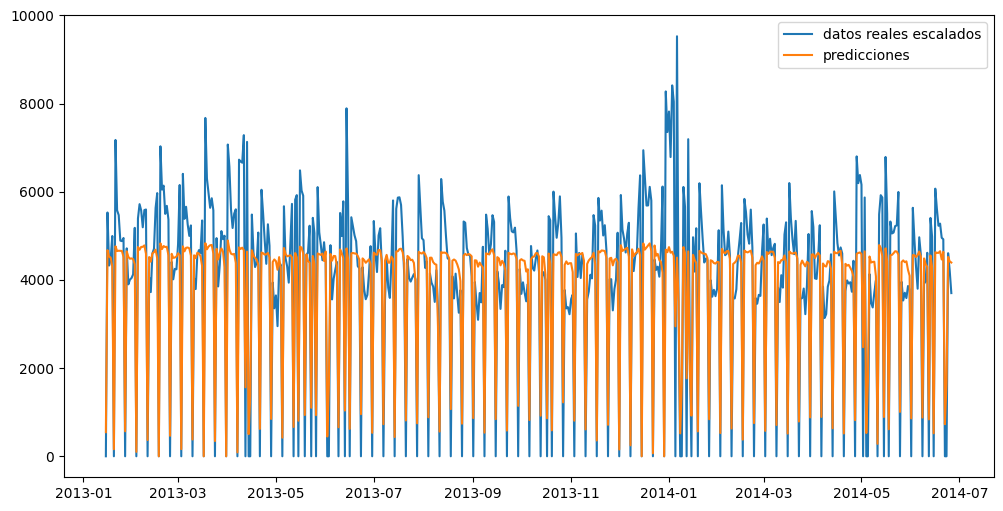

In [333]:
plt.figure(figsize=(12,6))
plt.plot(fechas_train, Sales_train, label="datos reales escalados")
plt.plot(fechas_train, y_train_pred, label="predicciones")
plt.legend(loc="upper right")

In [338]:
Sales_val=np.array(data_tienda1_val["Sales"]).reshape(-1, 1)
Sales_val.shape

(200, 1)

In [339]:
y_val_pred=scaler_target.inverse_transform(y_val_pred_scaled.reshape(-1, 1))
y_val_pred.shape

(200, 1)

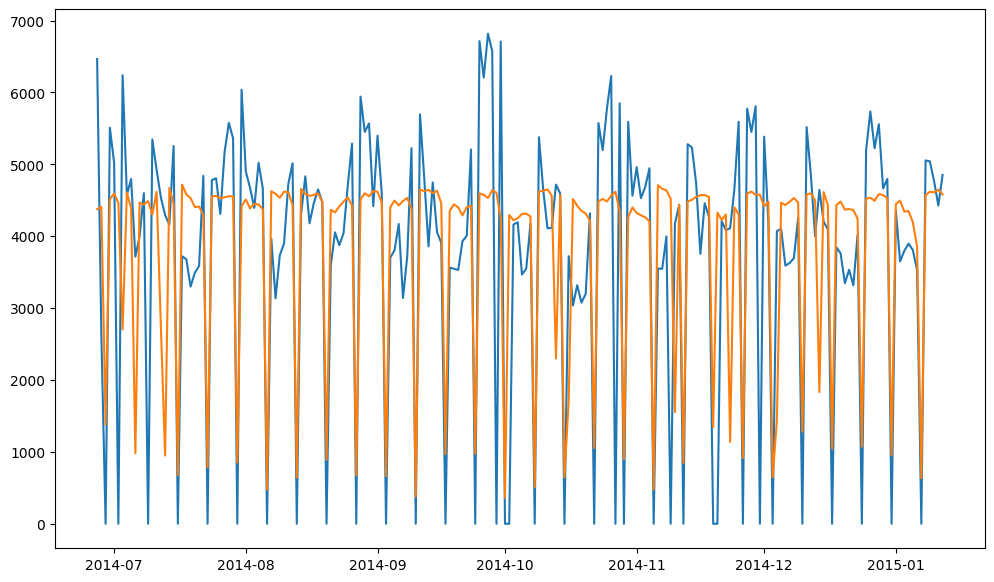

In [344]:
plt.figure(figsize=(12,7))

plt.plot(fechas_val, Sales_val, label="Datos reales")
plt.plot(fechas_val, y_val_pred, label="predicciones")
plt.show()

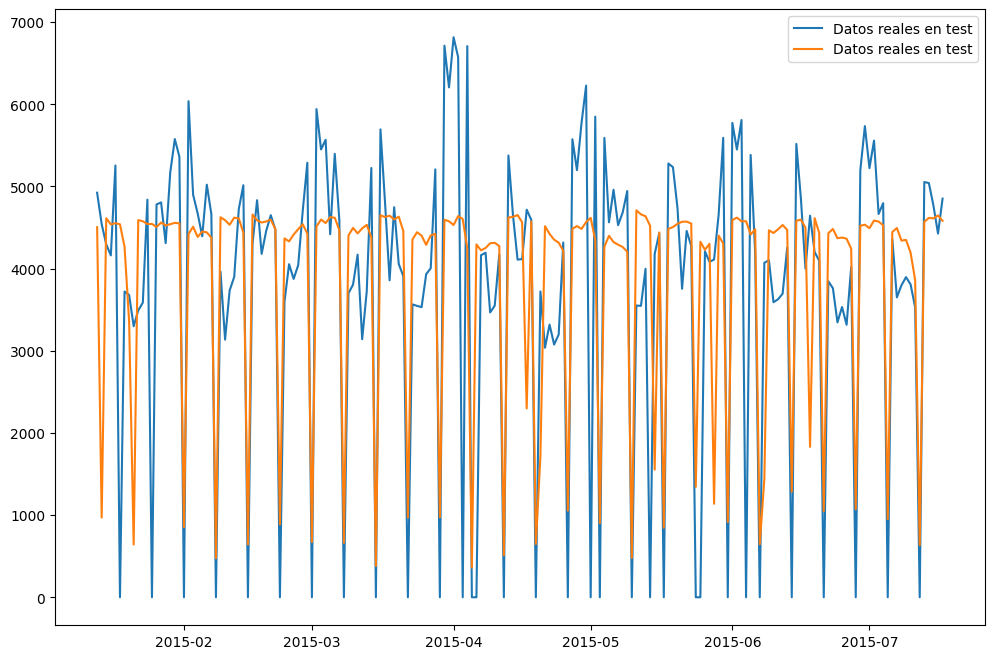

In [351]:
Sales_test=np.array(data_tienda1_test["Sales"]).reshape(-1,1)
y_test_pred=scaler_target.inverse_transform(y_test_pred_scaled.reshape(-1,1))

plt.figure(figsize=(12,8))
plt.plot(fechas_test, Sales_test, label="Datos reales en test")
plt.plot(fechas_test, y_test_pred, label="Datos reales en test")
plt.legend(loc="upper right")

**Ejercicio:**
### Segundo modelo: utilizamos la variable endógena y exógenas

In [355]:
df_tienda1_transf

,Sales,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,Id,festivo,mes
0,0.000000,1,2,2013-01-01,0,0,a,1,690197,1,1
1,0.774518,1,3,2013-01-02,1,0,0,1,988300,1,1
2,0.606029,1,4,2013-01-03,1,0,0,1,919910,1,1
3,0.628298,1,5,2013-01-04,1,0,0,1,662609,1,1
4,0.699868,1,6,2013-01-05,1,0,0,1,1008092,1,1
...,...,...,...,...,...,...,...,...,...,...,...
923,0.707851,1,1,2015-07-13,1,1,0,0,308477,0,7
924,0.706170,1,2,2015-07-14,1,1,0,0,704685,0,7
925,0.667655,1,3,2015-07-15,1,1,0,0,64663,0,7
926,0.620035,1,4,2015-07-16,1,1,0,0,324709,0,7


In [447]:
df_tienda1_transf["festivo"].unique()

array([1, 0])

In [448]:
from my_utils_series_temporales import int2dummy

min(mes), max(mes)

(np.int64(1), np.int64(12))

In [449]:
mes[:50]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2])

In [450]:
dummies_mes=int2dummy(mes, minimo=1, maximo=12)

In [451]:
min(day_of_week), max(day_of_week)

(np.int64(1), np.int64(7))

In [452]:
dummies_day_of_week=int2dummy(day_of_week, minimo=1, maximo=7)
dummies_day_of_week[:50]

array([[0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
 

In [453]:
festivo

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,

In [472]:
W=5
Series=[ Sales_transf, promo, festivo]
nombres_series = ["target_transf", "promo", "festivo"]
se_saben_antes = [False, True, True]

for i in range (0,12):
    Series.append(dummies_mes[:,i])
    se_saben_antes.append(True)

for i in range (0,7):
    Series.append(dummies_day_of_week[:,i])
    se_saben_antes.append(True)

In [473]:
for i in range (0,7):
    print(i)

0
1
2
3
4
5
6


In [474]:
X, y= enventanar(Series, target=0, se_saben_antes=se_saben_antes, W_in=W)

In [475]:
X.shape

(928, 5, 22)

In [476]:
Punto_corte=int(len(X[0])*0.8)
Nval=200

In [477]:
#Aux
X_aux=X[W:punto_corte]
fechas_aux=fechas[W:punto_corte]
target_aux=target[W:punto_corte]
y_aux=y[W:punto_corte]

#Training
X_train=X_aux[:-Nval]
fechas_train=fechas_aux[:-Nval]
target_train=target_aux[:-Nval]
y_train=y_aux[:-Nval]

#Validacion
X_val=X_aux[-Nval:]
fechas_val=fechas_aux[-Nval:]
target_val=target_aux[-Nval:]
y_val=y_aux[-Nval:]

#Test
X_test=X[punto_corte:]
fechas_test=fechas[punto_corte:]
target_test=target[punto_corte:]
y_test=y[punto_corte:]

In [478]:
print(f"X_train shape: {X_train.shape}, y_train {y_train.shape}, fechas_train {fechas_train.shape}")

X_train shape: (537, 5, 22), y_train (537,), fechas_train (537,)


In [479]:
print(f"X_val shape: {X_val.shape}, y_val {y_val.shape}, fechas_val {fechas_val.shape}")

X_val shape: (200, 5, 22), y_val (200,), fechas_val (200,)


In [480]:
print(f"X_test shape: {X_test.shape}, y_test {y_test.shape}, fechas_val {fechas_test.shape}")

X_test shape: (186, 5, 22), y_test (186,), fechas_val (186,)


In [481]:
X_train.shape[1:]

(5, 22)

In [482]:
from keras import Sequential
from keras.layers import Dense, LSTM, GRU
from keras.optimizers import RMSprop

model=Sequential()
model.add(GRU(10, input_shape=(X_train.shape[1:])))
model.add(Dense(1, activation="relu"))


optimizer_lstm= keras.optimizers.RMSprop(learning_rate=1/1000)

model.compile(optimizer=optimizer_lstm, loss="mean_squared_error")
model.summary()
          

c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\env-PC4-mbit\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 10)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,031 (4.03 KB)

 Trainable params: 1,031 (4.03 KB)

 Non-trainable params: 0 (0.00 B)

In [483]:
help(keras.callbacks.ModelCheckpoint)

Help on class ModelCheckpoint in module keras.src.callbacks.model_checkpoint:

class ModelCheckpoint(keras.src.callbacks.monitor_callback.MonitorCallback)
 |  ModelCheckpoint(filepath, monitor='val_loss', verbose=0, save_best_only=False, save_weights_only=False, mode='auto', save_freq='epoch', initial_value_threshold=None)
 |
 |  Callback to save the Keras model or model weights at some frequency.
 |
 |  `ModelCheckpoint` callback is used in conjunction with training using
 |  `model.fit()` to save a model or weights (in a checkpoint file) at some
 |  interval, so the model or weights can be loaded later to continue the
 |  training from the state saved.
 |
 |  A few options this callback provides include:
 |
 |  - Whether to only keep the model that has achieved the "best performance" so
 |    far, or whether to save the model at the end of every epoch regardless of
 |    performance.
 |  - Definition of "best"; which quantity to monitor and whether it should be
 |    maximized or min

In [484]:
from os import getcwd

ruta=getcwd()
best_model_variables_exo=ruta+"/model_var_exo_tienda1.keras"

In [485]:
# Entrenamiento del modelo 

from keras.callbacks import ModelCheckpoint

checkpoint=ModelCheckpoint(best_model_variables_exo, monitor='val_loss', verbose=0, save_best_only=True)

In [ ]:
from IPython.display import clear_output
epocas=400
train_loss_=[]
val_loss_=[]

for i in range (epocas): 
    history=model.fit(X_train, y_train, epochs=1, batch_size=64, validation_data=(X_val, y_val), verbose=2, callbacks=checkpoint)
    train_loss_.append(history.history["loss"])
    val_loss_.append(history.history["val_loss"])
    if(i%40==0):
        clear_output()
        grafica_entrenamiento(train_loss_, val_loss_)


In [ ]:
from keras.models import load_model

model = load_model(best_model_variables_exo)

In [ ]:
y_train_prediction = model.predict(X_train, verbose=0).flatten()
R2_score(y_train, y_train_prediction)

0.16887611121523216